# Predicting Business Profits Using Machine Learning Model

##### Esmeralda Bucio

In [99]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Data
df = pd.read_csv("Business_Analytics_Dataset_10000_Rows.csv")
df.head()


,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


## Introduction

##### This dataset includes synthetic data that was sourced from https://www.kaggle.com/datasets/amar5693/retail-business-analytics-dataset-10k-orders detailing more than 10,000 retail business transactions. I am going to create a machine learning linear regression model to demonstrate how to predict profit from variables such as the price of the unit, the quantity purchased, the products category, region of production, and more.

## Analysis

In [100]:
df.shape

(10000, 13)

In [101]:
# Data Cleaning

df.isna().sum()

Order_ID            0
Customer_ID         0
Order_Date          0
Region              0
Product_Category    0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Rate       0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64

##### This data is cleaned because it has no missing values.

In [102]:
X = df[["Discount_Rate", "Unit_Price", "Region", "Quantity", "Product_Category", "Customer_Segment"]]

In [103]:
y = df["Profit"]

In [104]:
# Data Splitting

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.20, 
    random_state = 425)

In [105]:
X_vtrain, X_validation, y_vtrain, y_validation = train_test_split(
    X_train, 
    y_train, 
    test_size = 0.20, 
    random_state = 425
)

In [106]:
# Data Preprocessing

numeric_features = ["Discount_Rate", "Unit_Price", "Quantity"]
categorical_features = ["Region", "Product_Category", "Customer_Segment"]

numeric_transformer = Pipeline(
    [("scaler", StandardScaler())]
)
categorical_transformer = Pipeline(
    [("encoder", OneHotEncoder(handle_unknown = "ignore"))]
)
column_transformer = ColumnTransformer(
    [("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)]
)

In [107]:
# Model Training

lm = Pipeline([
    ('preprocessor', column_transformer),
    ('regression', LinearRegression())
])

lm.fit(X_vtrain, y_vtrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [108]:
# Evaluating Model Performance

r2_train = r2_score(y_vtrain, lm.predict(X_vtrain))

print("Train R²:", r2_train)

Train R²: 0.7486726057050406


In [109]:
y_test_pred = lm.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)

Test R²: 0.7520170200460397
Test RMSE: 177.7417552032596


##### The model is answering 74.87% variability in the train data and 75.20% variability in the test data. Our model is performing well because it is accounting for a large amount of the variation in both the train and test data.

In [110]:
df["Profit"].mean()

np.float64(418.94976799999995)

In [111]:
df["Profit"].std()

np.float64(368.4184465215062)

In [112]:
df["Profit"].max()

np.float64(2292.42)

In [113]:
df["Profit"].min()

np.float64(1.97)

In [114]:
rmse_test / df["Profit"].mean()

np.float64(0.424255528417573)

(array([4057., 2408., 1489.,  946.,  561.,  295.,  148.,   65.,   25.,
           6.]),
 array([1.970000e+00, 2.310150e+02, 4.600600e+02, 6.891050e+02,
        9.181500e+02, 1.147195e+03, 1.376240e+03, 1.605285e+03,
        1.834330e+03, 2.063375e+03, 2.292420e+03]),
 <BarContainer object of 10 artists>)

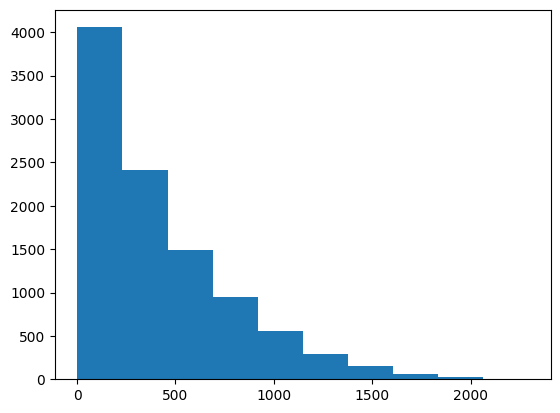

In [115]:
plt.hist(df["Profit"])

##### The model's RMSE is \$177.74. This means that the model's predictions are off by about \$178 on average. The mean amount of profit is \$418, which means the typical predicition error is about 42.4% of the average value. The RMSE is less than half the standard deviation of the profit, \$368.42, indicating that the model better explains the variability for the profit. Given the range of the profit is  \$1.97 - \$2292.42. The RSME is relatively small compared to the overall spread, meaning that the model is performing reasonably well. An important consideration is the right skew of the data, which could influence the model's prediction error. 

## Conclusion

##### In this report, we created a machine learning linear regression model to predict profit using various amount of quantitative and categorical variables. We were able to achieve an RMSE of \$177.74 and an R-squared value of 0.752, meaning that we are explaining about 75% of the variability in the data. Given the range of the profit \$1.97 -  \$2292.42, our RSME is relatively small, meaning that our model predicition error is moderate. The prediction error could be influenced by the right skew of the data which is important to consider. The model performs well but could be improved further by aiming to minimize predicition error. 
